In [1]:
# import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *
import pandas as pd

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
runs = [500, 1000, 1_000_0, 1_000_00, 1_000_000]

a1_0 = 100
b_a1 = 2
t1 = 10
d_a1 = 3.8*10**(-4)
T_a1 = 10

MI_b_a1 = np.zeros((len(runs),len(stat_names)))
MI_args = np.hstack(([1],np.arange(4,len(stat_names))))

### (1) Compute mutual information as a function of dataset size

In [3]:
run_count = 0

for run in runs:
    b_a1s = np.random.uniform(0.1*b_a1, 10*b_a1, size = run) 
    t1s = [t1]
    d_a1s = [d_a1]
    a1_0s = [a1_0]

    run_data_b_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(b_a1s)/8))(delayed(sum_sim)(a1_0, b_a1, t1, d_a1)
                                                  for a1_0 in a1_0s
                                                  for b_a1 in b_a1s
                                                  for t1 in t1s
                                                  for d_a1 in d_a1s))
    
    for i in MI_args:
        MI_b_a1[run_count, i] = calc_MI(run_data_b_a1[:,1],run_data_b_a1[:,i])
    
    run_count += 1

In [4]:
np.save('compute-MI.npy',run_data_b_a1)

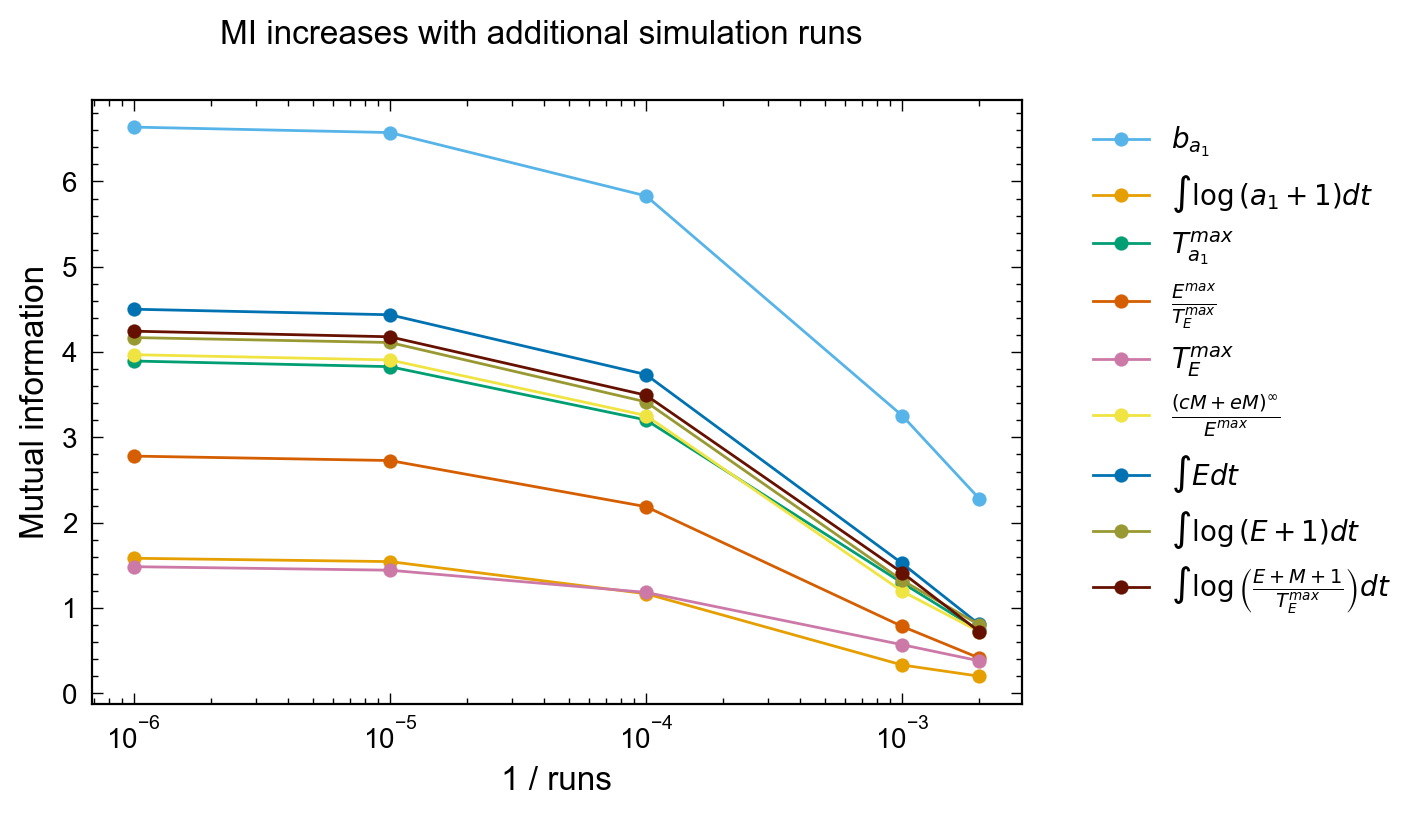

In [13]:
plt.plot(np.ones(len(runs))/runs, MI_b_a1[:,np.hstack(([1],np.arange(4,len(stat_names))))], 'o-', label = np.concatenate(([stat_names[1]],stat_names[4:]), axis = None))
plt.xlabel("1 / runs")
plt.ylabel("Mutual information")
plt.semilogx()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle('MI increases with additional simulation runs')
plt.savefig('MI-scales-with-runs.png', dpi=150, bbox_inches="tight")

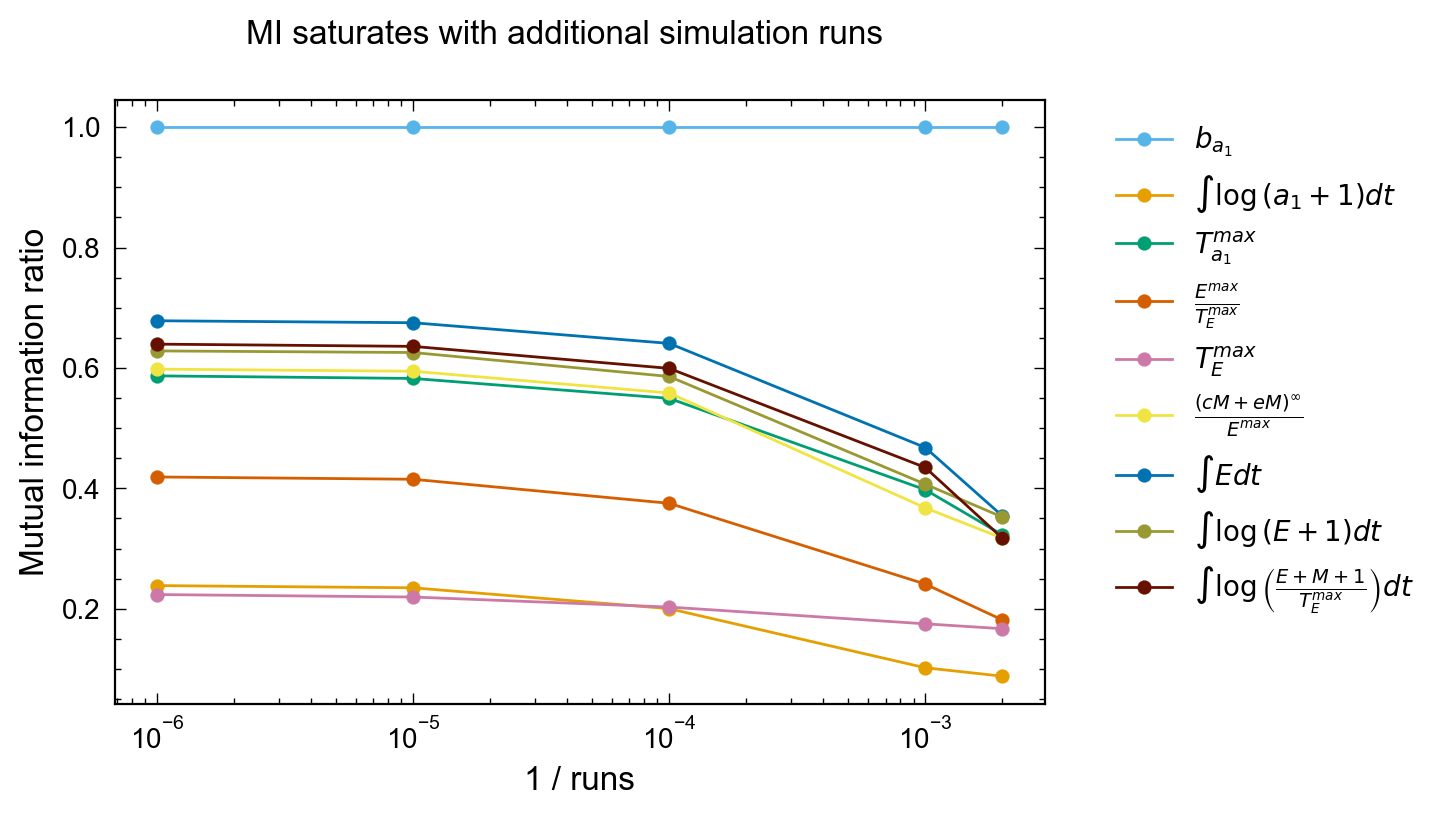

In [6]:
MI_b_a1_frac = np.zeros((len(runs),len(stat_names)))
for i in np.arange(len(runs)):
    MI_b_a1_frac[i,:] = MI_b_a1[i,:]/MI_b_a1[i,1]
 

plt.plot(np.ones(len(runs))/runs, MI_b_a1_frac[:,MI_args], 'o-',label = np.concatenate(([stat_names[1]],stat_names[4:]), axis = None))
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.xlabel("1 / runs")
plt.suptitle('MI saturates with additional simulation runs')
plt.ylabel("Mutual information ratio")
plt.semilogx()
plt.savefig('MI-stabilizes-with-runs.png', dpi=150, bbox_inches="tight")

### (2) Compute mutual information as a function of bin number

In [7]:
bin_nums = [10,100, 500, 1000, 10000]
MI_b_a1_bins = np.zeros((len(bin_nums),len(stat_names)))
run_count = 0
#run_data_b_a1 = np.load('compute-MI.npy')

for bin_num in bin_nums:

    for i in MI_args:
        MI_b_a1_bins[run_count, i] = calc_MI(run_data_b_a1[:,1],run_data_b_a1[:,i], 
                                             bin_num,
                                            correction = False)
    run_count += 1

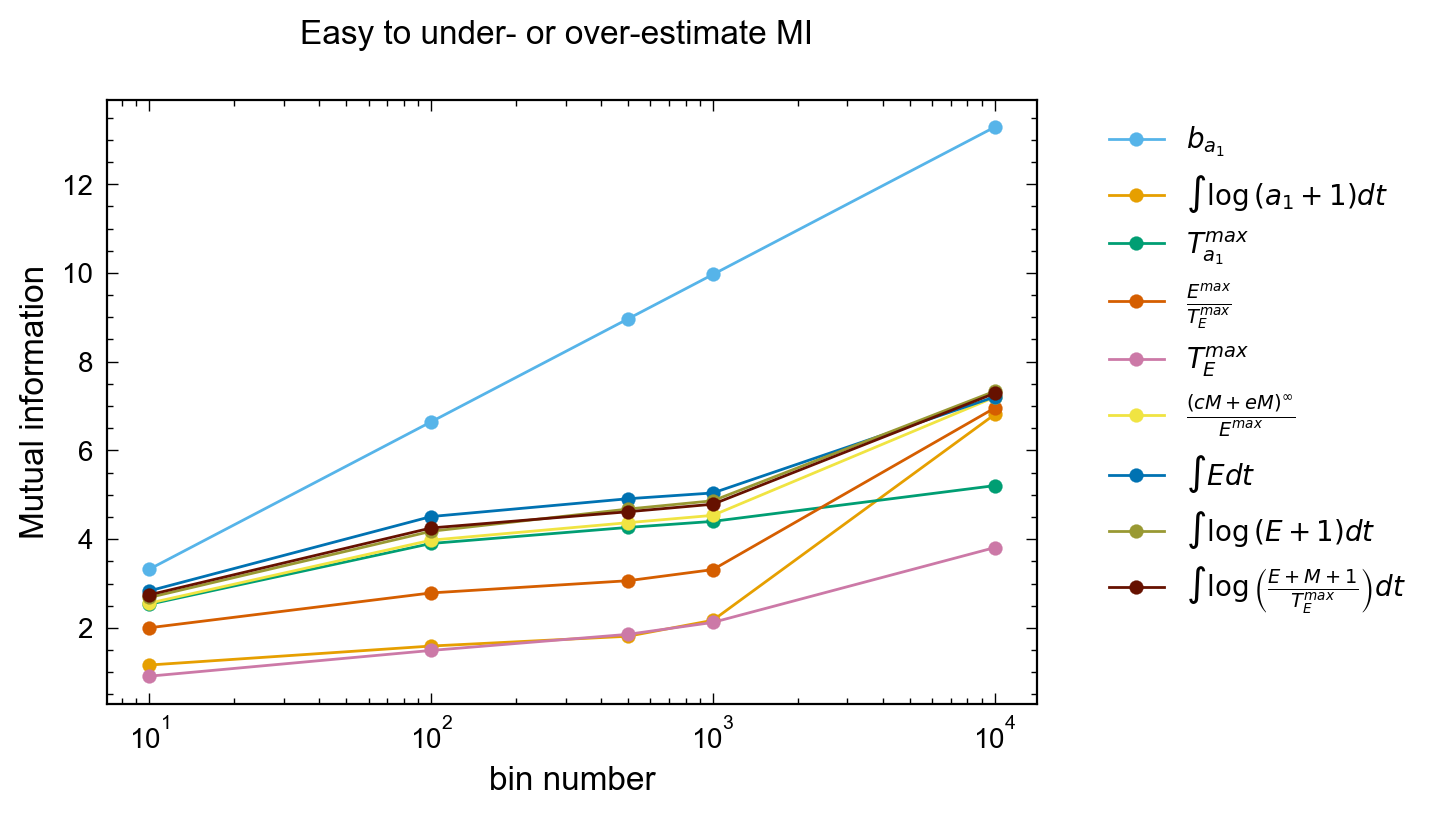

In [8]:
plt.plot(bin_nums, MI_b_a1_bins[:,np.hstack(([1],np.arange(4,len(stat_names))))], 'o-', label = np.concatenate(([stat_names[1]],stat_names[4:]), axis = None))
plt.xlabel("bin number")
plt.ylabel("Mutual information")
plt.semilogx()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle('Easy to under- or over-estimate MI')
plt.savefig('MI-varies-with-bin-nums.png', dpi=150, bbox_inches="tight")

In [9]:
bin_nums = [5, 10,50, 100, 500, 1000, 10000]
MI_b_a1_bins = np.zeros((len(bin_nums),len(stat_names)))
run_count = 0
#run_data_b_a1 = np.load('compute-MI.npy')

for bin_num in bin_nums:

    for i in MI_args:
        MI_b_a1_bins[run_count, i] = calc_MI(run_data_b_a1[:,1],
                                             (run_data_b_a1[:,i])[np.random.permutation((run_data_b_a1[:,i]).shape[0])], 
                                             bin_num,
                                            correction = False)
    run_count += 1

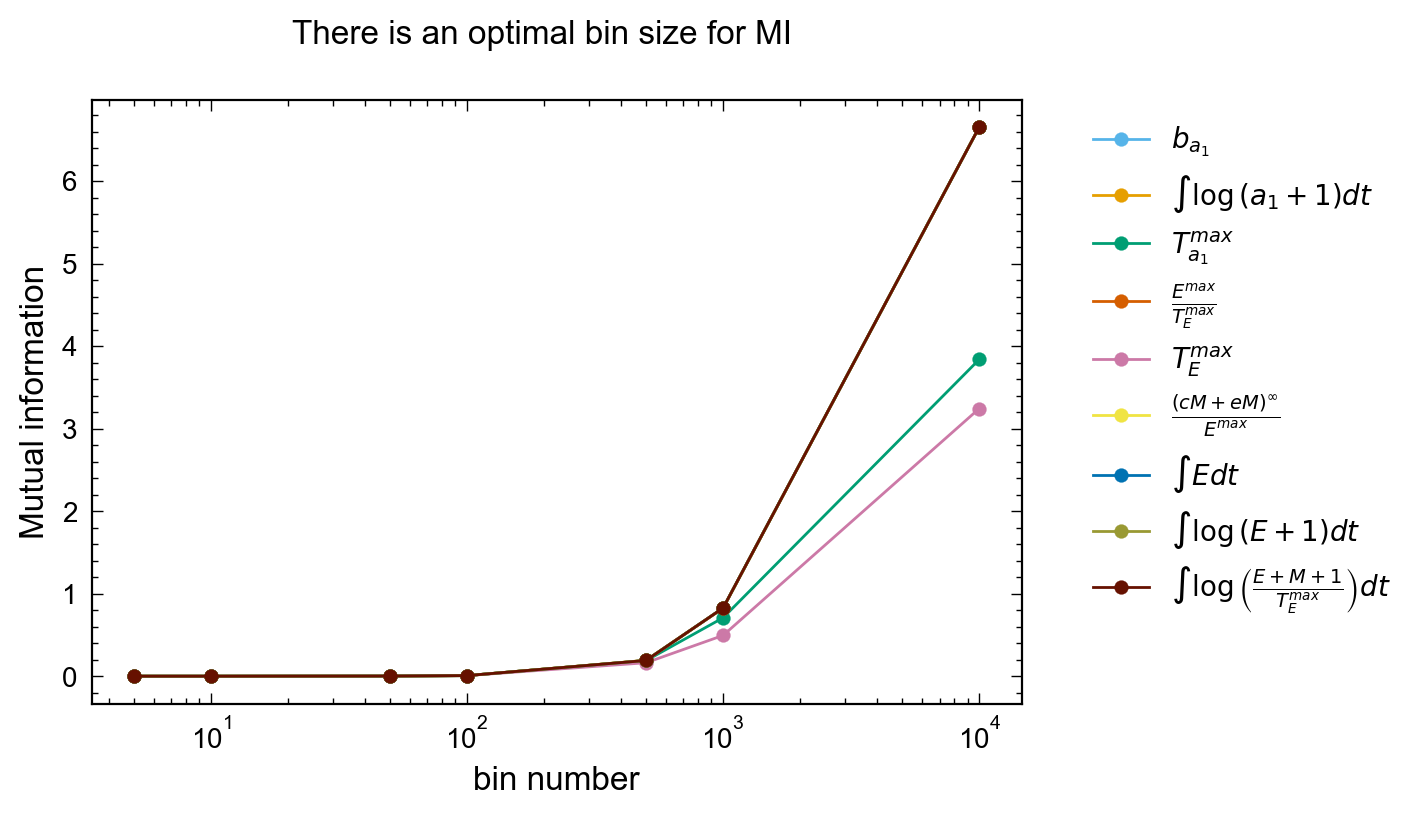

In [10]:
plt.plot(bin_nums, MI_b_a1_bins[:,np.hstack(([1],np.arange(4,len(stat_names))))], 'o-', label = np.concatenate(([stat_names[1]],stat_names[4:]), axis = None))
plt.xlabel("bin number")
plt.ylabel("Mutual information")
plt.semilogx()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle('There is an optimal bin size for MI')
plt.savefig('error-MI-varies-with-bin-nums.png', dpi=150, bbox_inches="tight")

In [11]:
MI_b_a1_bins[:,np.hstack(([1],np.arange(4,len(stat_names))))]

array([[8.55910190e-06, 9.98707861e-06, 5.88398964e-06, 9.62250591e-06,
        1.83852766e-05, 1.19267583e-05, 7.57690495e-06, 9.96448119e-06,
        1.16296422e-05],
       [6.96106138e-05, 5.98343970e-05, 4.70830579e-05, 5.94021502e-05,
        4.53155928e-05, 7.49739583e-05, 5.13386424e-05, 5.87720659e-05,
        5.72859570e-05],
       [1.72847077e-03, 1.74835919e-03, 1.73218977e-03, 1.76009892e-03,
        1.79067793e-03, 1.72583631e-03, 1.68771383e-03, 1.65502405e-03,
        1.68337369e-03],
       [7.01232144e-03, 6.98592348e-03, 7.04024376e-03, 7.12836985e-03,
        7.07422207e-03, 7.03904711e-03, 7.14627304e-03, 7.18256510e-03,
        7.09126818e-03],
       [1.90526764e-01, 1.90457233e-01, 1.88371190e-01, 1.91897375e-01,
        1.62774378e-01, 1.92147680e-01, 1.90799820e-01, 1.90882954e-01,
        1.90603786e-01],
       [8.25814243e-01, 8.25518339e-01, 7.07798739e-01, 8.26390369e-01,
        4.94176303e-01, 8.25268878e-01, 8.27209235e-01, 8.25567682e-01,
        8.2

In [10]:
_, out = pd.qcut(np.zeros(100), 100, retbins=True, duplicates = 'drop')
out

array([0.])

In [11]:
out.size

1

In [12]:
np.append(out, out +1)

array([0., 1.])